In [2]:
library(Seurat)
library(Signac)
library(GenomeInfoDb)
library(EnsDb.Hsapiens.v86)
library(ggplot2)
library(patchwork)
library(hdf5r)
library(future)
library(RColorBrewer)
library(dplyr)
library(Matrix)
library(BSgenome.Hsapiens.UCSC.hg38)
library(glue)
library(harmony)
library(matrixStats)
library(scales)
library(biomaRt)
library(curl)
library(goseq)
library(httr)
library(Scillus)
library(TFBSTools)
library(JASPAR2020)
library(ggridges)
library(ggrepel)
library(ggsignif)
library(qusage)
library(tidyverse)
library(data.table)
library(survival)
library(survminer)
library(car)
library(broom)
library(forestmodel)
httr::set_config(config(ssl_verifypeer = 0L))
set.seed(1234)
setwd("/home/jupyter/scATAC_analysis/edit/snatac-rcc-manuscript")
source("scripts/functions.r")


Attaching SeuratObject

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: ensembldb

Loading required packag

**Read in Fukagawa and TCGA KIRC clinical data and C1-C3 signature scores**

In [ ]:
model_df <- readRDS("processed_data/bulkATAC_TCGAKIRC_Fukagawa_signature_clinical.rds")


# Figure S2G: Association between ccRCC tumor states and overall survival

## Create OS model dataframe

Scale variables

In [5]:
model_df$Tumor_purity_raw <- model_df$Tumor_purity
model_df <- model_df %>%
  mutate(
    `Seq. depth` = unname(scale(total_fragments)[, 1]),
    Age = unname(scale(Age_u)[, 1]),
    `Tumor purity` = unname(scale(Tumor_purity)[, 1]),
    `C1 sig. prop.` = scale(C1_rel_raw)[, 1],
    `C2 sig. prop.` = scale(C2_rel_raw)[, 1],
    `C3 sig. prop.` = scale(C3_rel_raw)[, 1],
  )


Forest plot params

In [6]:
panels <- list(
  list(width = 0.01),
  list(width = 0.18, display = ~variable, fontface = "bold", heading = "Variable"),
  list(width = 0.1, display = ~level),
  list(width = 0.05, display = ~n, hjust = 1, heading = "N"),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(
    width = 0.15, item = "forest", hjust = 0.5, heading = "Estimate", linetype = "dashed",
    line_x = 0
  ),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(width = 0.12, display = ~ ifelse(reference, "Reference", sprintf(
    "%0.2f (%0.2f, %0.2f)",
    trans(estimate), trans(conf.low), trans(conf.high)
  )), display_na = NA),
  list(
    width = 0.075,
    display = ~ ifelse(reference, "", format.pval(p.value, digits = 1, nsmall = 3, eps = 0.001)),
    display_na = NA, hjust = 1, heading = "p"
  ),
  list(width = 0.01)
)


## C1

Call:
coxph(formula = Surv(OS_months, OS_event) ~ `C1 sig. prop.` + 
    Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, 
    data = model_df)

  n= 59, number of events= 10 
   (7 observations deleted due to missingness)

                        coef exp(coef)  se(coef)      z Pr(>|z|)   
`C1 sig. prop.`     -0.37965   0.68410   0.59822 -0.635  0.52567   
Age                  1.48364   4.40898   0.63166  2.349  0.01883 * 
SexM                -2.44698   0.08655   1.08472 -2.256  0.02408 * 
StageLate (III-IV)   5.18557 178.67454   1.58045  3.281  0.00103 **
`Tumor purity`      -0.22073   0.80193   0.78163 -0.282  0.77764   
`Seq. depth`         0.08380   1.08741   0.48591  0.172  0.86307   
CohortTCGA           1.16771   3.21463   1.59439  0.732  0.46393   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
`C1 sig. prop.`      0.68410   1.461770   0.21179    2.2097
Age                  4.40898   0.

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


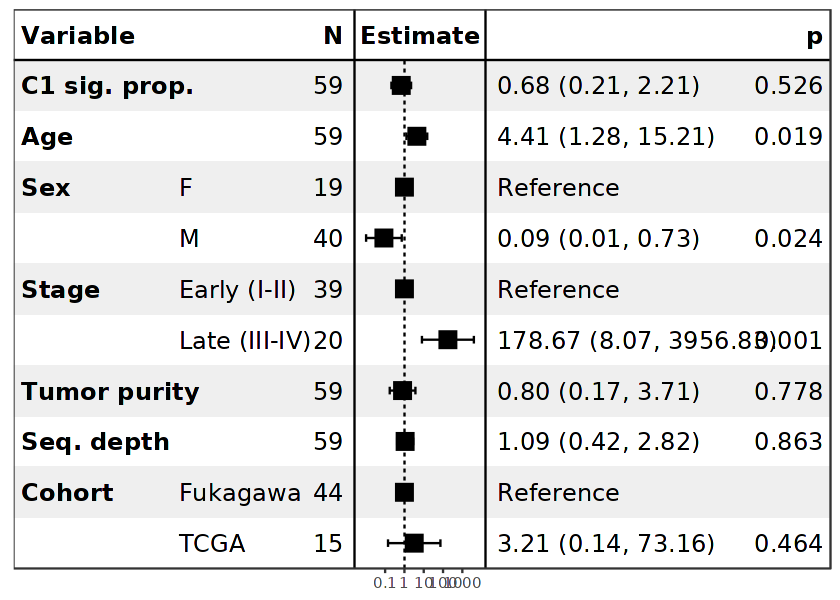

In [7]:
# Fit Cox model
cox_model <- coxph(Surv(OS_months, OS_event) ~ `C1 sig. prop.` + Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, data = model_df)
summary(cox_model)
options(repr.plot.width = 7, repr.plot.height = 5)
forest <- forest_model(cox_model, panels = panels)
forest


In [8]:
data.frame(vif(cox_model))


Warning message in vif.default(cox_model):
"No intercept: vifs may not be sensible."


,vif.cox_model.
,<dbl>
`C1 sig. prop.`,1.468106
Age,3.383683
Sex,2.219670
Stage,2.133369
`Tumor purity`,4.865829
`Seq. depth`,1.813113
Cohort,4.839388


## C2

Call:
coxph(formula = Surv(OS_months, OS_event) ~ `C2 sig. prop.` + 
    Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, 
    data = model_df)

  n= 59, number of events= 10 
   (7 observations deleted due to missingness)

                        coef exp(coef)  se(coef)      z Pr(>|z|)    
`C2 sig. prop.`     -0.18642   0.82993   0.67907 -0.275 0.783684    
Age                  1.61705   5.03822   0.67765  2.386 0.017020 *  
SexM                -2.45557   0.08581   1.11832 -2.196 0.028108 *  
StageLate (III-IV)   5.36742 214.30919   1.62927  3.294 0.000986 ***
`Tumor purity`      -0.65528   0.51930   0.81186 -0.807 0.419586    
`Seq. depth`         0.04916   1.05039   0.50581  0.097 0.922578    
CohortTCGA           2.07186   7.93954   1.97541  1.049 0.294259    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
`C2 sig. prop.`      0.82993   1.204927  0.219288    3.1410
Age                  5.03

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


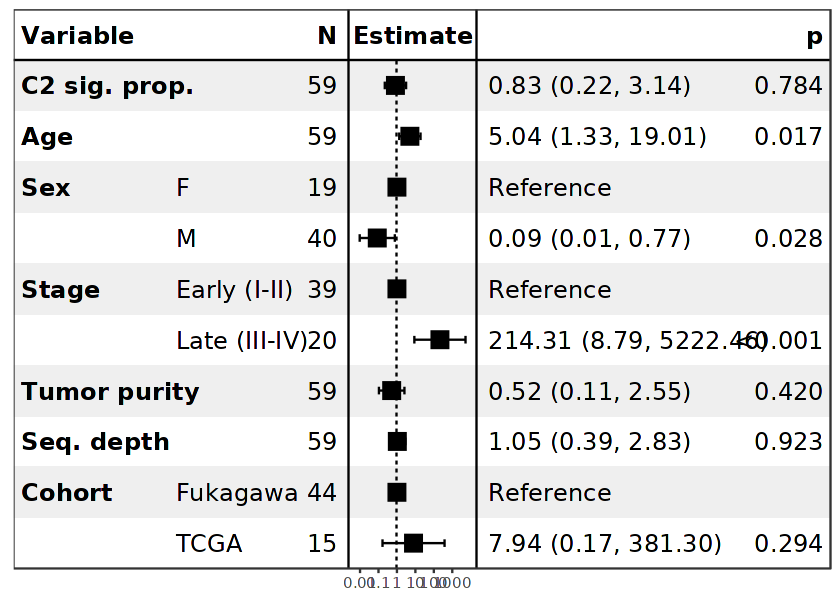

In [9]:
# Fit Cox model
cox_model <- coxph(Surv(OS_months, OS_event) ~ `C2 sig. prop.` + Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, data = model_df)
summary(cox_model)
options(repr.plot.width = 7, repr.plot.height = 5)
forest <- forest_model(cox_model, panels = panels)
forest


In [10]:
data.frame(vif(cox_model))


Warning message in vif.default(cox_model):
"No intercept: vifs may not be sensible."


,vif.cox_model.
,<dbl>
`C2 sig. prop.`,2.203390
Age,3.813417
Sex,2.355239
Stage,2.285336
`Tumor purity`,5.138569
`Seq. depth`,2.004892
Cohort,7.542990


## C3

Call:
coxph(formula = Surv(OS_months, OS_event) ~ `C3 sig. prop.` + 
    Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, 
    data = model_df)

  n= 59, number of events= 10 
   (7 observations deleted due to missingness)

                        coef exp(coef)  se(coef)      z Pr(>|z|)    
`C3 sig. prop.`      1.37848   3.96887   0.90517  1.523 0.127783    
Age                  1.28458   3.61315   0.60074  2.138 0.032489 *  
SexM                -1.18119   0.30691   1.34454 -0.879 0.379665    
StageLate (III-IV)   5.06840 158.91968   1.46135  3.468 0.000524 ***
`Tumor purity`      -0.03142   0.96907   0.79173 -0.040 0.968342    
`Seq. depth`        -0.81614   0.44213   0.79213 -1.030 0.302863    
CohortTCGA           2.93521  18.82548   1.71097  1.716 0.086249 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
`C3 sig. prop.`       3.9689   0.251961   0.67327    23.396
Age                   3.6

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


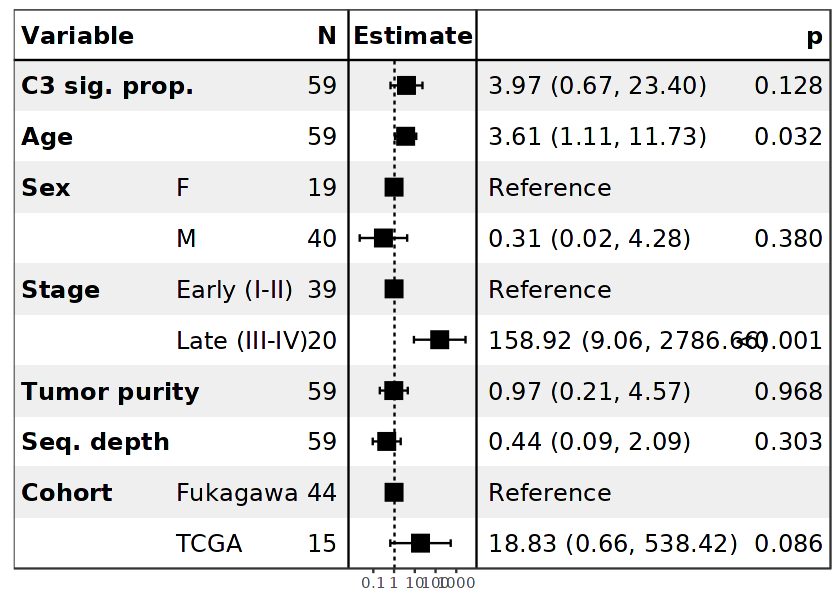

In [11]:
# Fit Cox model
cox_model <- coxph(Surv(OS_months, OS_event) ~ `C3 sig. prop.` + Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, data = model_df)
summary(cox_model)
options(repr.plot.width = 7, repr.plot.height = 5)
forest <- forest_model(cox_model, panels = panels)
forest


In [12]:
data.frame(vif(cox_model))


Warning message in vif.default(cox_model):
"No intercept: vifs may not be sensible."


,vif.cox_model.
,<dbl>
`C3 sig. prop.`,8.117941
Age,2.752684
Sex,3.319792
Stage,1.834080
`Tumor purity`,4.570945
`Seq. depth`,5.235994
Cohort,5.669491


## Combined plot

In [13]:
cox_model <- coxph(Surv(OS_months, OS_event) ~ `C1 sig. prop.` + `Sex` + Stage + `Age` + `Tumor purity` + Cohort + `Seq. depth`, data = model_df)
c1_os <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  filter(term == "`C1 sig. prop.`") %>%
  mutate(program = "C1", outcome = "OS")

cox_model <- coxph(Surv(OS_months, OS_event) ~ `C2 sig. prop.` + `Sex` + Stage + `Age` + `Tumor purity` + Cohort + `Seq. depth`, data = model_df)
c2_os <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  filter(term == "`C2 sig. prop.`") %>%
  mutate(program = "C2", outcome = "OS")

cox_model <- coxph(Surv(OS_months, OS_event) ~ `C3 sig. prop.` + `Sex` + Stage + `Age` + `Tumor purity` + Cohort + `Seq. depth`, data = model_df)
c3_os <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  filter(term == "`C3 sig. prop.`") %>%
  mutate(program = "C3", outcome = "OS")

combined_results <- bind_rows(c1_os, c2_os, c3_os)


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


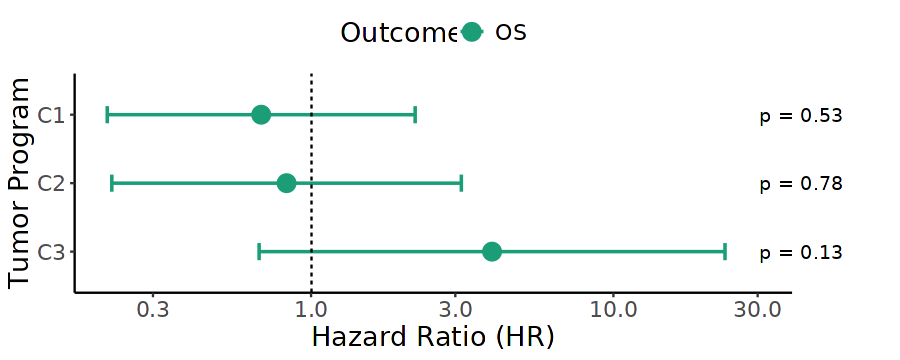

In [14]:
combined_results$outcome <- factor(combined_results$outcome, levels = c("OS", "DFS"))
combined_results$program <- factor(combined_results$program, levels = c("C3", "C2", "C1"))

x_pos_pval <- max(combined_results$conf.high, na.rm = TRUE) * 1.3
options(repr.plot.width = 7.5, repr.plot.height = 3)
ggplot(combined_results, aes(y = program, x = estimate, xmin = conf.low, xmax = conf.high, color = outcome, shape = outcome)) +
  theme_classic() +
  # Add thick horizontal CIs
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
    height = 0.25,
    size = 0.75,
    position = position_dodge(width = 0.7)
  ) +
  # Add normal-sized points
  geom_point(position = position_dodge(width = 0.7), size = 5) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  geom_text(
    aes(
      x = x_pos_pval,
      label = ifelse(p.value < 0.05,
        paste0("p = ", signif(p.value, 2), "*"),
        paste0("p = ", signif(p.value, 2))
      )
    ),
    hjust = 0,
    position = position_dodge(width = 0.7),
    size = 4,
    color = ifelse(combined_results$p.value < 0.05, "red", "black")
  ) +
  scale_x_log10() +
  labs(
    x = "Hazard Ratio (HR)",
    y = "Tumor Program",
    color = "Outcome"
  ) +
  theme(
    legend.position = "top",
    text = element_text(size = 16, color = "black"),
    plot.margin = margin(t = 5, r = 65, b = 5, l = 5)
  ) +
  scale_color_manual(
    name = "Outcome",
    values = c("DFS" = "#d95f02", "OS" = "#1b9e77")
  ) +
  scale_shape_manual(
    name = "Outcome",
    values = c("DFS" = 17, "OS" = 16) # circle and triangle
  ) +
  coord_cartesian(clip = "off")


# Figure S2G-H: Association between ccRCC tumor states and disease-free survival

## Create DFS model dataframe

In [15]:
model_dfs <- model_df %>%
  filter(!is.na(DFS_event)) %>%
  mutate(
    `Seq. depth` = unname(scale(total_fragments)[, 1]),
    Age = unname(scale(Age_u)[, 1]),
    `Tumor purity` = unname(scale(Tumor_purity)[, 1]),
    `C1 sig. prop.` = scale(C1_rel_raw)[, 1],
    `C2 sig. prop.` = scale(C2_rel_raw)[, 1],
    `C3 sig. prop.` = scale(C3_rel_raw)[, 1]
  )


## C1

Call:
coxph(formula = Surv(DFS_months, DFS_event) ~ `C1 sig. prop.` + 
    Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, 
    data = model_dfs)

  n= 48, number of events= 8 
   (6 observations deleted due to missingness)

                       coef exp(coef) se(coef)      z Pr(>|z|)  
`C1 sig. prop.`    -0.64838   0.52289  0.39804 -1.629   0.1033  
Age                -0.53431   0.58608  0.59920 -0.892   0.3726  
SexM               -0.32071   0.72563  0.87139 -0.368   0.7128  
StageLate (III-IV)  1.46379   4.32230  0.96305  1.520   0.1285  
`Tumor purity`      1.49916   4.47794  0.67267  2.229   0.0258 *
`Seq. depth`       -0.29894   0.74160  0.49687 -0.602   0.5474  
CohortTCGA         -2.30665   0.09959  1.59433 -1.447   0.1480  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
`C1 sig. prop.`      0.52289     1.9124  0.239662     1.141
Age                  0.58608     1.7063  0.181096     1

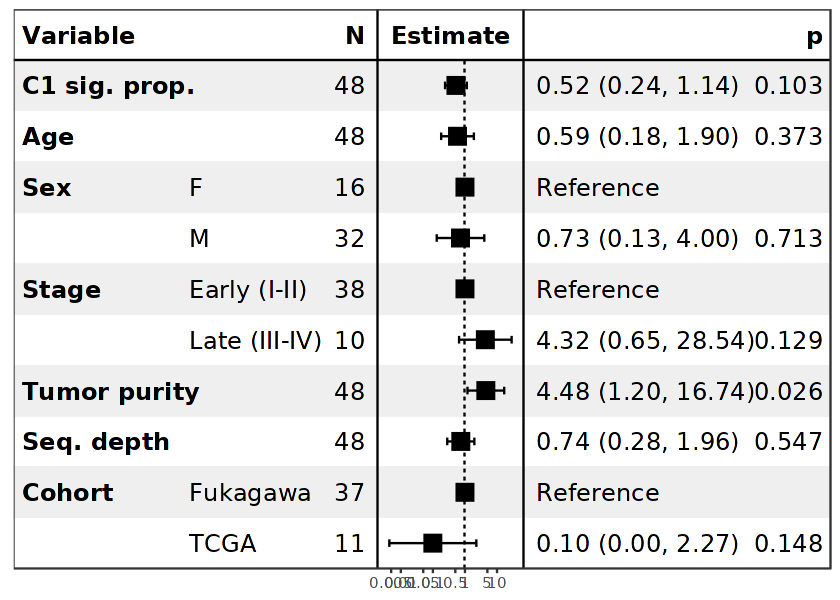

In [17]:
# Fit Cox model
cox_model <- coxph(Surv(DFS_months, DFS_event) ~ `C1 sig. prop.` + Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, data = model_dfs)
summary(cox_model)
options(repr.plot.width = 7, repr.plot.height = 5)
forest <- forest_model(cox_model, panels = panels)
forest


In [18]:
data.frame(vif(cox_model))


Warning message in vif.default(cox_model):
"No intercept: vifs may not be sensible."


,vif.cox_model.
,<dbl>
`C1 sig. prop.`,1.372487
Age,1.909080
Sex,1.128184
Stage,1.587418
`Tumor purity`,2.371264
`Seq. depth`,1.231670
Cohort,2.181667


## C2

Call:
coxph(formula = Surv(DFS_months, DFS_event) ~ `C2 sig. prop.` + 
    Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, 
    data = model_dfs)

  n= 48, number of events= 8 
   (6 observations deleted due to missingness)

                      coef exp(coef) se(coef)      z Pr(>|z|)  
`C2 sig. prop.`     0.3811    1.4639   0.3717  1.025   0.3052  
Age                -0.5208    0.5940   0.6150 -0.847   0.3971  
SexM               -0.3892    0.6776   0.8946 -0.435   0.6635  
StageLate (III-IV)  1.3849    3.9945   0.9718  1.425   0.1541  
`Tumor purity`      1.2366    3.4440   0.6332  1.953   0.0508 .
`Seq. depth`       -0.2376    0.7885   0.4446 -0.535   0.5930  
CohortTCGA         -1.9469    0.1427   1.6232 -1.199   0.2304  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
`C2 sig. prop.`       1.4639     0.6831  0.706559     3.033
Age                   0.5940     1.6834  0.177955     1.983
Sex

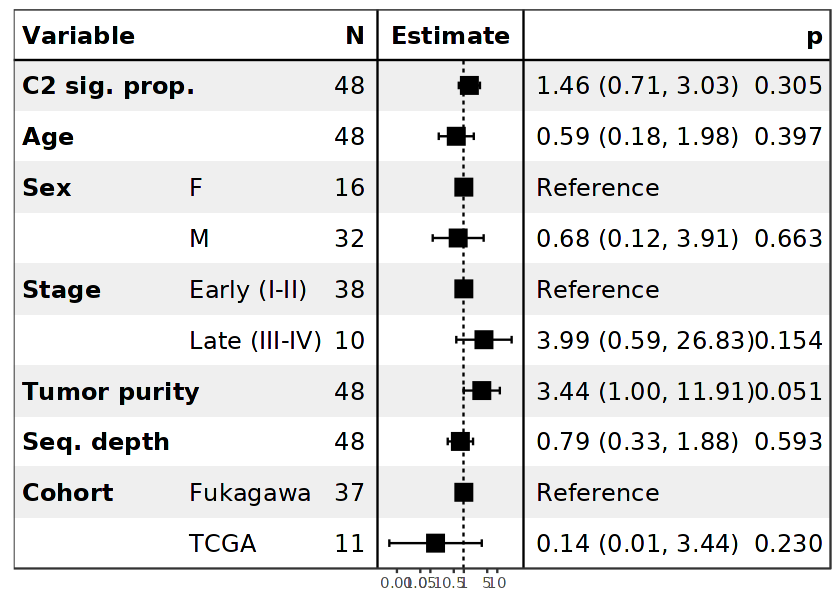

In [19]:
# Fit Cox model
cox_model <- coxph(Surv(DFS_months, DFS_event) ~ `C2 sig. prop.` + Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, data = model_dfs)
summary(cox_model)
options(repr.plot.width = 7, repr.plot.height = 5)
forest <- forest_model(cox_model, panels = panels)
forest


In [20]:
data.frame(vif(cox_model))


Warning message in vif.default(cox_model):
"No intercept: vifs may not be sensible."


,vif.cox_model.
,<dbl>
`C2 sig. prop.`,1.337225
Age,2.028400
Sex,1.191023
Stage,1.691886
`Tumor purity`,2.156700
`Seq. depth`,1.168138
Cohort,2.275574


## C3

Call:
coxph(formula = Surv(DFS_months, DFS_event) ~ `C3 sig. prop.` + 
    Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, 
    data = model_dfs)

  n= 48, number of events= 8 
   (6 observations deleted due to missingness)

                      coef exp(coef) se(coef)      z Pr(>|z|)  
`C3 sig. prop.`     1.0390    2.8264   0.5275  1.970   0.0489 *
Age                -0.4768    0.6207   0.7227 -0.660   0.5094  
SexM                0.2145    1.2392   0.8912  0.241   0.8098  
StageLate (III-IV)  1.6848    5.3912   1.1277  1.494   0.1352  
`Tumor purity`      1.5548    4.7342   0.6198  2.509   0.0121 *
`Seq. depth`       -0.4135    0.6613   0.4939 -0.837   0.4024  
CohortTCGA         -1.5184    0.2191   1.5947 -0.952   0.3410  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
`C3 sig. prop.`       2.8264     0.3538   1.00508     7.948
Age                   0.6207     1.6110   0.15059     2.559
Sex

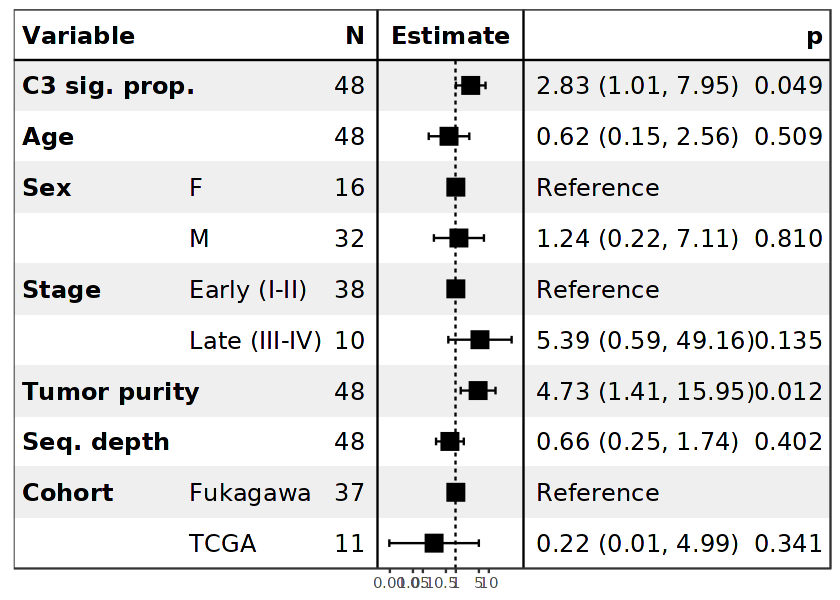

In [21]:
# Fit Cox model
cox_model <- coxph(Surv(DFS_months, DFS_event) ~ `C3 sig. prop.` + Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, data = model_dfs)
summary(cox_model)
options(repr.plot.width = 7, repr.plot.height = 5)
forest <- forest_model(cox_model, panels = panels)
forest


In [22]:
data.frame(vif(cox_model))


Warning message in vif.default(cox_model):
"No intercept: vifs may not be sensible."


,vif.cox_model.
,<dbl>
`C3 sig. prop.`,1.851039
Age,1.731033
Sex,1.181543
Stage,2.185618
`Tumor purity`,2.135383
`Seq. depth`,1.349846
Cohort,2.184815


### Figure S2H: Association between ccRCC tumor states and disease-free survival, controlling for BAP1 mutation status

In [23]:
bap1_df <- model_dfs %>%
  filter(`BAP1 mut. status` %in% c("pLOF", "WT")) %>%
  mutate(
    `BAP1 mut. status` = factor(`BAP1 mut. status`, levels = c("WT", "pLOF")),
    `Seq. depth` = unname(scale(total_fragments)[, 1]),
    Age = unname(scale(Age_u)[, 1]),
    `Tumor purity` = unname(scale(Tumor_purity)[, 1]),
    `C1 sig. prop.` = scale(C1_rel_raw)[, 1],
    `C2 sig. prop.` = scale(C2_rel_raw)[, 1],
    `C3 sig. prop.` = scale(C3_rel_raw)[, 1],
  )


Call:
coxph(formula = Surv(DFS_months, DFS_event) ~ `C3 sig. prop.` + 
    `BAP1 mut. status` + Age + Sex + Stage + `Tumor purity` + 
    `Seq. depth` + Cohort, data = bap1_df)

  n= 45, number of events= 8 
   (6 observations deleted due to missingness)

                          coef exp(coef) se(coef)      z Pr(>|z|)  
`C3 sig. prop.`         1.0075    2.7387   0.6281  1.604   0.1087  
`BAP1 mut. status`pLOF  2.5684   13.0453   1.3584  1.891   0.0587 .
Age                    -0.5867    0.5562   0.9485 -0.619   0.5362  
SexM                    0.8953    2.4480   1.1190  0.800   0.4237  
StageLate (III-IV)      1.3380    3.8113   1.4921  0.897   0.3699  
`Tumor purity`          1.6788    5.3593   0.6856  2.449   0.0143 *
`Seq. depth`           -0.9912    0.3711   0.6060 -1.636   0.1019  
CohortTCGA             -1.3343    0.2633   1.6869 -0.791   0.4289  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                       exp(coef) exp(-coef) lower .95 upper .95


Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
"Unable to resize forest panel to be smaller than its heading; consider a smaller text size"


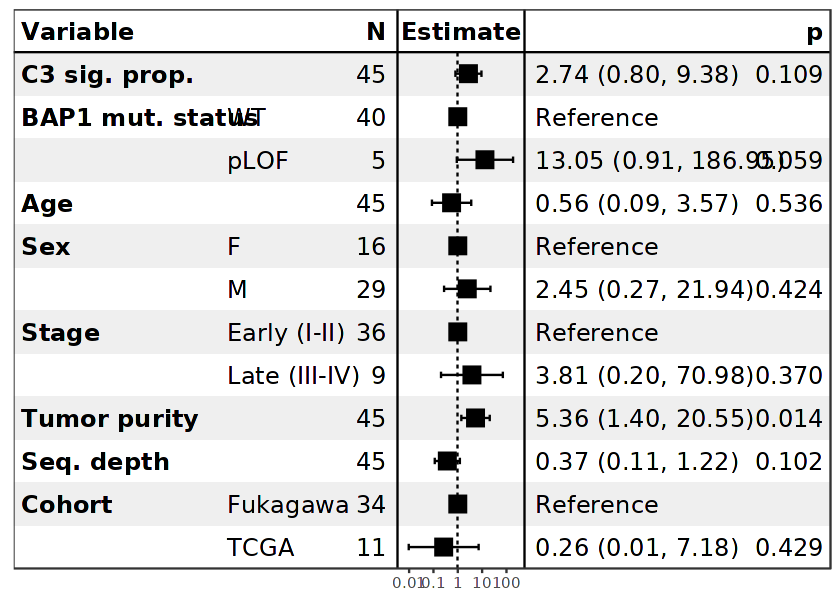

In [24]:
# Fit Cox model
cox_model <- coxph(Surv(DFS_months, DFS_event) ~ `C3 sig. prop.` + `BAP1 mut. status` + Age + Sex + Stage + `Tumor purity` + `Seq. depth` + Cohort, data = bap1_df)
summary(cox_model)
options(repr.plot.width = 7, repr.plot.height = 5)
forest <- forest_model(cox_model, panels = panels)
forest


## Combined plot

In [25]:
cox_model <- coxph(Surv(DFS_months, DFS_event) ~ `C1 sig. prop.` + `Sex` + Stage + `Age` + `Tumor purity` + Cohort + `Seq. depth`, data = model_dfs)
c1_dfs <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  filter(term == "`C1 sig. prop.`") %>%
  mutate(program = "C1", outcome = "DFS")

cox_model <- coxph(Surv(DFS_months, DFS_event) ~ `C2 sig. prop.` + `Sex` + Stage + `Age` + `Tumor purity` + Cohort + `Seq. depth`, data = model_dfs)
c2_dfs <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  filter(term == "`C2 sig. prop.`") %>%
  mutate(program = "C2", outcome = "DFS")

cox_model <- coxph(Surv(DFS_months, DFS_event) ~ `C3 sig. prop.` + `Sex` + Stage + `Age` + `Tumor purity` + Cohort + `Seq. depth`, data = model_dfs)
c3_dfs <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  filter(term == "`C3 sig. prop.`") %>%
  mutate(program = "C3", outcome = "DFS")

combined_results <- bind_rows(c1_dfs, c2_dfs, c3_dfs)


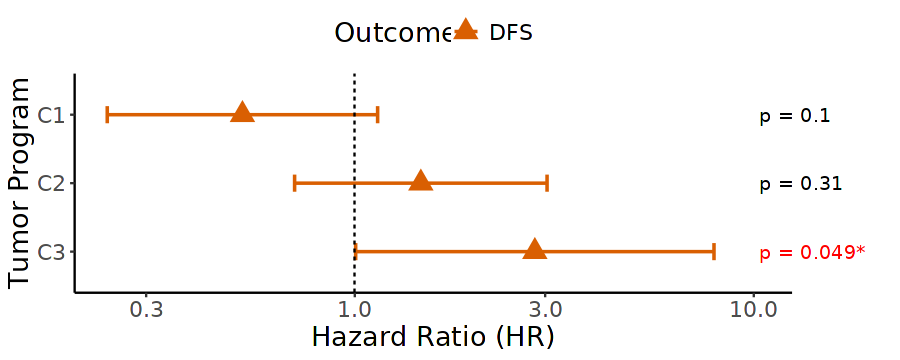

In [26]:
library(ggplot2)
combined_results$outcome <- factor(combined_results$outcome, levels = c("OS", "DFS"))
combined_results$program <- factor(combined_results$program, levels = c("C3", "C2", "C1"))

x_pos_pval <- max(combined_results$conf.high, na.rm = TRUE) * 1.3
options(repr.plot.width = 7.5, repr.plot.height = 3)
ggplot(combined_results, aes(y = program, x = estimate, xmin = conf.low, xmax = conf.high, color = outcome, shape = outcome)) +
  theme_classic() +
  # Add thick horizontal CIs
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
    height = 0.25,
    size = 0.75,
    position = position_dodge(width = 0.7)
  ) +
  # Add normal-sized points
  geom_point(position = position_dodge(width = 0.7), size = 5) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  geom_text(
    aes(
      x = x_pos_pval,
      label = ifelse(p.value < 0.05,
        paste0("p = ", signif(p.value, 2), "*"),
        paste0("p = ", signif(p.value, 2))
      )
    ),
    hjust = 0,
    position = position_dodge(width = 0.7),
    size = 4,
    color = ifelse(combined_results$p.value < 0.05, "red", "black")
  ) +
  scale_x_log10() +
  labs(
    x = "Hazard Ratio (HR)",
    y = "Tumor Program",
    color = "Outcome"
  ) +
  theme(
    legend.position = "top",
    text = element_text(size = 16, color = "black"),
    plot.margin = margin(t = 5, r = 65, b = 5, l = 5)
  ) +
  scale_color_manual(
    name = "Outcome",
    values = c("DFS" = "#d95f02", "OS" = "#1b9e77")
  ) +
  scale_shape_manual(
    name = "Outcome",
    values = c("DFS" = 17, "OS" = 16) # circle and triangle
  ) +
  coord_cartesian(clip = "off")


# Figure 2J: Summary visualization: Association between ccRCC tumor states and OS, DFS

In [27]:
combined_results <- bind_rows(c1_os, c2_os, c3_os, c1_dfs, c2_dfs, c3_dfs)


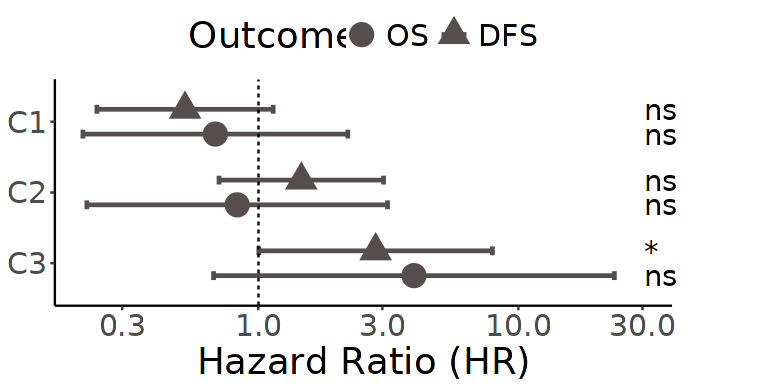

In [28]:
library(ggplot2)
combined_results$outcome <- factor(combined_results$outcome, levels = c("OS", "DFS"))
combined_results$program <- factor(combined_results$program, levels = c("C3", "C2", "C1"))

x_pos_pval <- max(combined_results$conf.high, na.rm = TRUE) * 1.3
options(repr.plot.width = 6.5, repr.plot.height = 3.25)
ggplot(combined_results, aes(y = program, x = estimate, xmin = conf.low, xmax = conf.high, color = outcome, shape = outcome)) +
  theme_classic() +
  # Add thick horizontal CIs
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
    height = 0.25,
    size = 1,
    position = position_dodge(width = 0.7)
  ) +
  # Add normal-sized points
  geom_point(position = position_dodge(width = 0.7), size = 6.5) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  geom_text(
    (
      aes(
        x = x_pos_pval,
        label = ifelse(p.value < 0.05,
          "*",
          "ns"
        )
      )
    ),
    hjust = 0,
    position = position_dodge(width = 0.7),
    size = 6,
    color = "black"
  ) +
  scale_x_log10() +
  labs(
    x = "Hazard Ratio (HR)",
    color = "Outcome"
  ) +
  theme(
    legend.position = "top",
    text = element_text(size = 22, color = "black"),
    plot.margin = margin(t = 5, r = 65, b = 5, l = 5),
    axis.title.y = element_blank()
  ) +
  scale_color_manual(
    name = "Outcome",
    values = c("DFS" = "#564e4e", "OS" = "#564e4e")
  ) +
  scale_shape_manual(
    name = "Outcome",
    values = c("DFS" = 17, "OS" = 16) # circle and triangle
  ) +
  coord_cartesian(clip = "off")


# Figure 2K: Kaplan-Meier curves - Association between C3 program and DFS

In [29]:
categorize_quartiles <- function(x) {
  q1 <- quantile(x, 0.25, na.rm = TRUE)
  q2 <- quantile(x, 0.50, na.rm = TRUE)
  q3 <- quantile(x, 0.75, na.rm = TRUE)

  cut(x,
    breaks = c(-Inf, q1, q2, q3, Inf),
    labels = c("Q1", "Q2", "Q3", "Q4"),
    include.lowest = TRUE
  )
}


## DFS, proportions, early stage

### Get quartiles into DF

In [32]:
signature_cat_df <- model_dfs %>%
  filter(Stage == "Early (I-II)") %>%
  dplyr::select(sample, C1_rel_raw, C2_rel_raw, C3_rel_raw)

# Add new columns with quartiles
signature_cat_df <- signature_cat_df %>%
  mutate(
    C1_quartile = factor(categorize_quartiles(C1_rel_raw),
      levels = c("Q1", "Q2", "Q3", "Q4")
    ),
    C2_quartile = factor(categorize_quartiles(C2_rel_raw),
      levels = c("Q1", "Q2", "Q3", "Q4")
    ),
    C3_quartile = factor(categorize_quartiles(C3_rel_raw),
      levels = c("Q1", "Q2", "Q3", "Q4")
    )
  )


# merge back into full model_df
model_dfs_km <- model_dfs %>%
  left_join(signature_cat_df %>% dplyr::select(sample, ends_with("_quartile")),
    by = "sample"
  )


### Figure 2K: Top C3 quartile vs rest

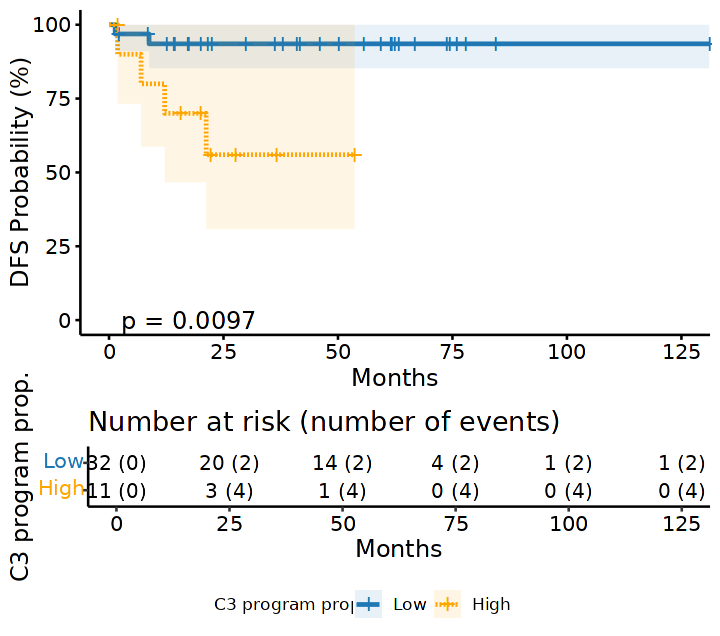

In [35]:
options(repr.plot.width = 6, repr.plot.height = 5.3)
model_dfs_km <- model_dfs_km %>% mutate(C3_top_vs_rest = ifelse(C3_quartile == "Q4", "Top Quartile", "Rest"))
fit <- survfit(Surv(DFS_months, DFS_event) ~ C3_top_vs_rest, data = model_dfs_km)
fontsize_plot <- 14
ggsurvplot(fit,
  conf.int = TRUE,
  conf.int.alpha = 0.1,
  fun = "pct",
  risk.table = "nrisk_cumevents",
  size = 1,
  linetype = "strata",
  ylab = "DFS Probability (%)",
  xlab = "Months",
  pval = TRUE,
  palette = c("#1f77b4", "#FFA500"),
  legend = "bottom",
  legend.title = "C3 program prop.",
  legend.labs = c("Low", "High"),
  risk.table.height = 0.3,
  risk.table.fontsize = fontsize_plot * 0.3
)


Cox UVA p-value

In [37]:
cox_model <- coxph(Surv(DFS_months, DFS_event) ~ factor(C3_top_vs_rest), data = model_dfs_km)
summary(cox_model)


Call:
coxph(formula = Surv(DFS_months, DFS_event) ~ factor(C3_top_vs_rest), 
    data = model_dfs_km)

  n= 43, number of events= 6 
   (11 observations deleted due to missingness)

                                     coef exp(coef) se(coef)     z Pr(>|z|)  
factor(C3_top_vs_rest)Top Quartile 1.9335    6.9137   0.8677 2.228   0.0259 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                                   exp(coef) exp(-coef) lower .95 upper .95
factor(C3_top_vs_rest)Top Quartile     6.914     0.1446     1.262     37.87

Concordance= 0.712  (se = 0.102 )
Likelihood ratio test= 5.31  on 1 df,   p=0.02
Wald test            = 4.97  on 1 df,   p=0.03
Score (logrank) test = 6.7  on 1 df,   p=0.01
